# Token Reversal — Clean Comparison

This notebook mirrors the structure of `MNIST_final.ipynb` for the reversal task.

We compare four methods:

- `reinforce`: vanilla REINFORCE
- `delightful`: Delightful Policy Gradient (DG)
- `entropy_hv`: REINFORCE + exact entropy gradient (`PG - beta * H`)
- `entropy_lv`: REINFORCE + score-function entropy estimator (DistG-style)

For `batch_size=4`:

1. Hyperparameter sweep (single seed).
2. Select best hyperparameters by **final sequence error** (lower is better).
3. Final multi-seed run with best hyperparameters.
4. Plot mean ± stderr sequence error curves.

## Protocol

- Task: binary token reversal, horizon `H=10`, vocab size `M=2`
- Model: decoder-only transformer (`d_model=64`, `2` layers, `2` heads)
- Reward: `bag_of_tokens` trajectory reward
- Entropy regularization: **per-token**
- Budget mode: `updates` (fixed optimizer updates)
- Optimizer updates: `400`
- Sweep seed: `0`
- Final seeds: `0..4`

In [7]:
import itertools
import math
import random
from dataclasses import dataclass, replace
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Categorical


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


@dataclass
class Config:
    H: int = 10
    M: int = 2
    d_model: int = 64
    nhead: int = 2
    num_layers: int = 2
    ff_mult: int = 4
    dropout: float = 0.0

    batch_size: int = 4
    training_budget: int = 400
    budget_mode: str = "updates"  # "episodes" or "updates"

    lr: float = 1e-3
    grad_clip: float = 1.0
    eta: float = 1.0

    reward_mode: str = "bag_of_tokens"
    num_eval_sequences: int = 512

    @property
    def bos_token(self) -> int:
        return self.M

    @property
    def sep_token(self) -> int:
        return self.M + 1

    @property
    def vocab_size(self) -> int:
        return self.M + 2

    @property
    def max_context_len(self) -> int:
        return 2 * self.H + 2

    @property
    def num_updates(self) -> int:
        if self.budget_mode == "updates":
            return self.training_budget
        if self.budget_mode == "episodes":
            if self.training_budget % self.batch_size != 0:
                raise ValueError(
                    "training_budget must be divisible by batch_size when budget_mode='episodes'"
                )
            return self.training_budget // self.batch_size
        raise ValueError(f"Unknown budget_mode: {self.budget_mode}")

    @property
    def total_episodes(self) -> int:
        if self.budget_mode == "updates":
            return self.training_budget * self.batch_size
        if self.budget_mode == "episodes":
            return self.training_budget
        raise ValueError(f"Unknown budget_mode: {self.budget_mode}")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sample_batch(batch_size: int, cfg: Config, device: torch.device = DEVICE):
    x = torch.randint(low=0, high=cfg.M, size=(batch_size, cfg.H), device=device)
    y = torch.flip(x, dims=[1])
    return x, y


class DecoderOnlyTransformer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.max_context_len, cfg.d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model,
            nhead=cfg.nhead,
            dim_feedforward=cfg.ff_mult * cfg.d_model,
            dropout=cfg.dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=cfg.num_layers)
        self.final_ln = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.M)

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = tokens.shape
        positions = torch.arange(seq_len, device=tokens.device).unsqueeze(0).expand(batch_size, -1)
        hidden = self.token_emb(tokens) + self.pos_emb(positions)

        causal_mask = torch.triu(
            torch.ones((seq_len, seq_len), dtype=torch.bool, device=tokens.device),
            diagonal=1,
        )
        hidden = self.transformer(hidden, mask=causal_mask)
        hidden = self.final_ln(hidden)
        return self.head(hidden)


def build_prompt(x: torch.Tensor, cfg: Config) -> torch.Tensor:
    bos = torch.full((x.size(0), 1), cfg.bos_token, dtype=torch.long, device=x.device)
    sep = torch.full((x.size(0), 1), cfg.sep_token, dtype=torch.long, device=x.device)
    return torch.cat([bos, x, sep], dim=1)


def compute_trajectory_returns(actions: torch.Tensor, targets: torch.Tensor, reward_mode: str) -> torch.Tensor:
    correct = (actions == targets).float()
    if reward_mode == "bag_of_tokens":
        returns = correct.mean(dim=1, keepdim=True)
    elif reward_mode == "sequential":
        prefix_correct = torch.cumprod(correct, dim=1)
        returns = prefix_correct.mean(dim=1, keepdim=True)
    else:
        raise ValueError(f"Unknown reward_mode: {reward_mode}")
    return returns


def rollout_policy(model: nn.Module, x: torch.Tensor, y: torch.Tensor, cfg: Config) -> Dict[str, torch.Tensor]:
    prompt = build_prompt(x, cfg)
    sampled_tokens: List[torch.Tensor] = []
    log_probs: List[torch.Tensor] = []
    logits_per_step: List[torch.Tensor] = []

    for _ in range(cfg.H):
        if sampled_tokens:
            generated = torch.stack(sampled_tokens, dim=1)
            context = torch.cat([prompt, generated], dim=1)
        else:
            context = prompt

        logits = model(context)[:, -1, :]
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        sampled_tokens.append(action)
        log_probs.append(log_prob)
        logits_per_step.append(logits)

    actions = torch.stack(sampled_tokens, dim=1)
    returns = compute_trajectory_returns(actions, y, cfg.reward_mode)

    return {
        "actions": actions,
        "log_probs": torch.stack(log_probs, dim=1),
        "logits": torch.stack(logits_per_step, dim=1),
        "returns": returns,
    }


def compute_trajectory_advantages(returns: torch.Tensor, horizon: int) -> torch.Tensor:
    baseline = returns.mean(dim=0, keepdim=True)
    advantages = returns - baseline
    return advantages.expand(-1, horizon)


def per_token_entropy(logits: torch.Tensor) -> torch.Tensor:
    probs = torch.softmax(logits, dim=-1)
    logp_all = torch.log_softmax(logits, dim=-1)
    return -(probs * logp_all).sum(dim=-1)


def reinforce_loss(log_probs: torch.Tensor, advantages: torch.Tensor) -> torch.Tensor:
    return -(advantages.detach() * log_probs).mean()


def delightful_loss(log_probs: torch.Tensor, advantages: torch.Tensor, eta: float = 1.0):
    adv = advantages.detach()
    surprisal = (-log_probs).detach()
    gate = torch.sigmoid((adv * surprisal) / eta).detach()
    loss = -(gate * adv * log_probs).mean()
    return loss, {"avg_gate": gate.mean().item()}


def entropy_hv_loss(log_probs: torch.Tensor, logits: torch.Tensor, advantages: torch.Tensor, beta: float) -> torch.Tensor:
    # Exact entropy gradient through logits.
    pg = -(advantages.detach() * log_probs).mean()
    H = per_token_entropy(logits).mean()
    return pg - beta * H


def entropy_lv_loss(log_probs: torch.Tensor, logits: torch.Tensor, advantages: torch.Tensor, beta: float) -> torch.Tensor:
    # Score-function entropy estimator (DistG-style):
    # w_t = (R-b) - beta * (log pi(a_t) + H_t)
    H_detached = per_token_entropy(logits).detach()
    weights = advantages.detach() - beta * (log_probs.detach() + H_detached)
    return -(weights * log_probs).mean()


@torch.no_grad()
def greedy_sequence_error(model: nn.Module, cfg: Config, num_sequences: int = None) -> float:
    num_sequences = num_sequences or cfg.num_eval_sequences
    x, y = sample_batch(num_sequences, cfg)
    prompt = build_prompt(x, cfg)
    generated: List[torch.Tensor] = []

    for _ in range(cfg.H):
        if generated:
            prefix = torch.stack(generated, dim=1)
            context = torch.cat([prompt, prefix], dim=1)
        else:
            context = prompt

        logits = model(context)[:, -1, :]
        next_token = logits.argmax(dim=-1)
        generated.append(next_token)

    preds = torch.stack(generated, dim=1)
    return (preds != y).float().mean().item()


def train_one_method(
    method: str,
    seed: int,
    cfg: Config,
    beta: Optional[float] = None,
) -> Dict[str, List[float]]:
    assert method in {"reinforce", "delightful", "entropy_hv", "entropy_lv"}
    if method in {"entropy_hv", "entropy_lv"} and beta is None:
        raise ValueError("beta must be provided for entropy methods")

    set_seed(seed)
    model = DecoderOnlyTransformer(cfg).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    history = {
        "episodes": [0],
        "sequence_error": [greedy_sequence_error(model, cfg)],
        "loss": [],
    }

    for update_idx in range(cfg.num_updates):
        model.train()
        x, y = sample_batch(cfg.batch_size, cfg)
        rollout = rollout_policy(model, x, y, cfg)
        advantages = compute_trajectory_advantages(rollout["returns"], cfg.H)

        if method == "reinforce":
            loss = reinforce_loss(rollout["log_probs"], advantages)
        elif method == "delightful":
            loss, _ = delightful_loss(rollout["log_probs"], advantages, eta=cfg.eta)
        elif method == "entropy_hv":
            loss = entropy_hv_loss(rollout["log_probs"], rollout["logits"], advantages, beta=beta)
        else:  # entropy_lv
            loss = entropy_lv_loss(rollout["log_probs"], rollout["logits"], advantages, beta=beta)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()

        model.eval()
        episodes = (update_idx + 1) * cfg.batch_size
        seq_error = greedy_sequence_error(model, cfg)

        history["episodes"].append(episodes)
        history["sequence_error"].append(seq_error)
        history["loss"].append(loss.item())

    return history


def summarize_runs(curves: List[np.ndarray]) -> Dict[str, np.ndarray]:
    stacked = np.stack(curves, axis=0)
    stderr = (
        stacked.std(axis=0, ddof=1) / math.sqrt(stacked.shape[0])
        if stacked.shape[0] > 1
        else np.zeros_like(stacked[0])
    )
    return {
        "mean": stacked.mean(axis=0),
        "stderr": stderr,
        "raw": stacked,
    }


BASE_CFG = Config()
BASE_CFG

Using device: cpu


Config(H=10, M=2, d_model=64, nhead=2, num_layers=2, ff_mult=4, dropout=0.0, batch_size=4, training_budget=400, budget_mode='updates', lr=0.001, grad_clip=1.0, eta=1.0, reward_mode='bag_of_tokens', num_eval_sequences=512)

In [8]:
# ── Global experiment settings ───────────────────────────────────────────────
SWEEP_SEED = 0
FINAL_SEEDS = list(range(5))

BATCH_SIZES = [4]
LR_VALUES = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
BETA_VALUES = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

METHODS_NO_BETA = ["reinforce", "delightful"]
METHODS_WITH_BETA = ["entropy_hv", "entropy_lv"]
ALL_METHODS = METHODS_NO_BETA + METHODS_WITH_BETA

print("Configured batch sizes:", BATCH_SIZES)
print("Learning-rate grid:", LR_VALUES)
print("Beta grid:", BETA_VALUES)
print("Final seeds:", FINAL_SEEDS)

Configured batch sizes: [4, 100]
Learning-rate grid: [0.0001, 0.0003, 0.001, 0.003, 0.01]
Beta grid: [0.001, 0.003, 0.01, 0.03, 0.1]
Final seeds: [0, 1, 2, 3, 4]


In [9]:
def run_sweep_for_batch(batch_size: int):
    cfg = replace(BASE_CFG, batch_size=batch_size)
    print(
        f"\n=== Sweep | batch_size={batch_size}, total_episodes={cfg.total_episodes}, updates={cfg.num_updates} ==="
    )

    sweep_results = {m: {} for m in ALL_METHODS}
    best_hparams = {}

    # Methods without beta
    for method in METHODS_NO_BETA:
        best_lr = None
        best_final_err = float("inf")

        for lr in LR_VALUES:
            run_cfg = replace(cfg, lr=lr)
            print(f"[sweep][bs={batch_size}] {method:10s} lr={lr:.0e}")
            hist = train_one_method(method=method, seed=SWEEP_SEED, cfg=run_cfg)

            final_err = hist["sequence_error"][-1]
            sweep_results[method][lr] = {
                "history": hist,
                "final_error": final_err,
            }

            if final_err < best_final_err:
                best_final_err = final_err
                best_lr = lr

        best_hparams[method] = {
            "lr": best_lr,
            "beta": None,
            "final_sweep_error": best_final_err,
        }

    # Methods with beta
    for method in METHODS_WITH_BETA:
        best_lr = None
        best_beta = None
        best_final_err = float("inf")

        for lr, beta in itertools.product(LR_VALUES, BETA_VALUES):
            run_cfg = replace(cfg, lr=lr)
            print(f"[sweep][bs={batch_size}] {method:10s} lr={lr:.0e} beta={beta:.0e}")
            hist = train_one_method(method=method, seed=SWEEP_SEED, cfg=run_cfg, beta=beta)

            final_err = hist["sequence_error"][-1]
            sweep_results[method][(lr, beta)] = {
                "history": hist,
                "final_error": final_err,
            }

            if final_err < best_final_err:
                best_final_err = final_err
                best_lr = lr
                best_beta = beta

        best_hparams[method] = {
            "lr": best_lr,
            "beta": best_beta,
            "final_sweep_error": best_final_err,
        }

    print(f"Best hyperparameters for batch_size={batch_size}:")
    for method in ALL_METHODS:
        hp = best_hparams[method]
        if hp["beta"] is None:
            print(
                f"  {method:10s}: lr={hp['lr']:.0e} | final_sweep_error={hp['final_sweep_error']:.4f}"
            )
        else:
            print(
                f"  {method:10s}: lr={hp['lr']:.0e} beta={hp['beta']:.0e} | final_sweep_error={hp['final_sweep_error']:.4f}"
            )

    return sweep_results, best_hparams


sweep_results_all = {}
best_hparams_all = {}
for bs in BATCH_SIZES:
    sweep_results_all[bs], best_hparams_all[bs] = run_sweep_for_batch(bs)


=== Sweep | batch_size=4, total_episodes=1600, updates=400 ===
[sweep][bs=4] reinforce  lr=1e-04
[sweep][bs=4] reinforce  lr=3e-04
[sweep][bs=4] reinforce  lr=1e-03
[sweep][bs=4] reinforce  lr=3e-03
[sweep][bs=4] reinforce  lr=1e-02
[sweep][bs=4] delightful lr=1e-04
[sweep][bs=4] delightful lr=3e-04
[sweep][bs=4] delightful lr=1e-03
[sweep][bs=4] delightful lr=3e-03
[sweep][bs=4] delightful lr=1e-02
[sweep][bs=4] entropy_hv lr=1e-04 beta=1e-03
[sweep][bs=4] entropy_hv lr=1e-04 beta=3e-03
[sweep][bs=4] entropy_hv lr=1e-04 beta=1e-02
[sweep][bs=4] entropy_hv lr=1e-04 beta=3e-02
[sweep][bs=4] entropy_hv lr=1e-04 beta=1e-01
[sweep][bs=4] entropy_hv lr=3e-04 beta=1e-03
[sweep][bs=4] entropy_hv lr=3e-04 beta=3e-03
[sweep][bs=4] entropy_hv lr=3e-04 beta=1e-02
[sweep][bs=4] entropy_hv lr=3e-04 beta=3e-02
[sweep][bs=4] entropy_hv lr=3e-04 beta=1e-01
[sweep][bs=4] entropy_hv lr=1e-03 beta=1e-03
[sweep][bs=4] entropy_hv lr=1e-03 beta=3e-03
[sweep][bs=4] entropy_hv lr=1e-03 beta=1e-02
[sweep][bs=

KeyboardInterrupt: 

In [ ]:
def run_final_for_batch(batch_size: int, best_hparams: Dict[str, Dict[str, float]]):
    cfg = replace(BASE_CFG, batch_size=batch_size)
    print(
        f"\n=== Final runs | batch_size={batch_size}, total_episodes={cfg.total_episodes}, updates={cfg.num_updates} ==="
    )

    final_results = {}
    shared_episodes = None

    for method in ALL_METHODS:
        lr = best_hparams[method]["lr"]
        beta = best_hparams[method]["beta"]
        run_cfg = replace(cfg, lr=lr)
        histories = []

        if beta is None:
            print(f"\n[{method}] lr={lr:.0e}")
        else:
            print(f"\n[{method}] lr={lr:.0e} beta={beta:.0e}")

        for seed in FINAL_SEEDS:
            hist = train_one_method(method=method, seed=seed, cfg=run_cfg, beta=beta)
            histories.append(hist)
            print(f"  seed={seed} final_seq_error={hist['sequence_error'][-1]:.4f}")

        curves = [np.array(h["sequence_error"]) for h in histories]
        losses = [np.array(h["loss"]) for h in histories]
        shared_episodes = np.array(histories[0]["episodes"])

        final_results[method] = {
            "sequence_error": summarize_runs(curves),
            "loss": summarize_runs(losses),
            "histories": histories,
            "lr": lr,
            "beta": beta,
        }

    final_results["episodes"] = shared_episodes
    return final_results


final_results_all = {}
for bs in BATCH_SIZES:
    final_results_all[bs] = run_final_for_batch(bs, best_hparams_all[bs])


=== Final runs | batch_size=4, total_episodes=1600, updates=400 ===

[reinforce] lr=3e-04
  seed=0 final_seq_error=0.2381
  seed=1 final_seq_error=0.2123
  seed=2 final_seq_error=0.2734
  seed=3 final_seq_error=0.3078
  seed=4 final_seq_error=0.3361

[delightful] lr=3e-04
  seed=0 final_seq_error=0.1891
  seed=1 final_seq_error=0.0859
  seed=2 final_seq_error=0.2107
  seed=3 final_seq_error=0.1061
  seed=4 final_seq_error=0.2990

[entropy_hv] lr=1e-03 beta=1e-01
  seed=0 final_seq_error=0.0170
  seed=1 final_seq_error=0.0006
  seed=2 final_seq_error=0.0000
  seed=3 final_seq_error=0.0000
  seed=4 final_seq_error=0.1182

[entropy_lv] lr=1e-03 beta=3e-02
  seed=0 final_seq_error=0.0000
  seed=1 final_seq_error=0.0002
  seed=2 final_seq_error=0.0000
  seed=3 final_seq_error=0.0000
  seed=4 final_seq_error=0.0000

=== Final runs | batch_size=100, total_episodes=1600, updates=16 ===

[reinforce] lr=3e-03
  seed=0 final_seq_error=0.3332
  seed=1 final_seq_error=0.4010
  seed=2 final_seq_err

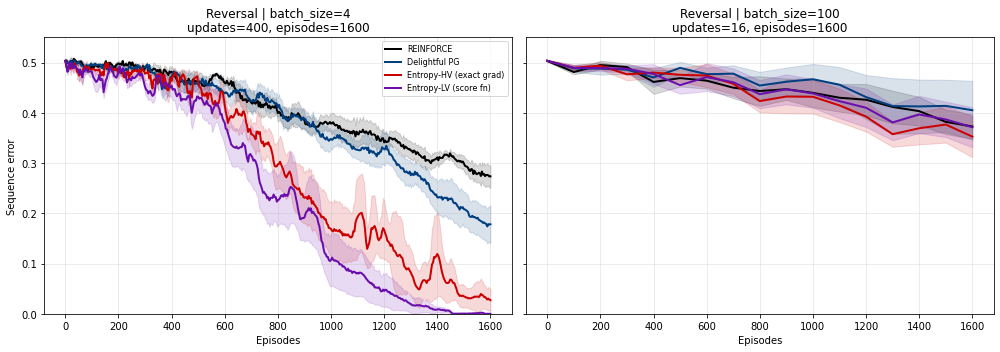

In [ ]:
# ── Plot: one panel per batch size ──────────────────────────────────────────
COLORS = {
    "reinforce": "black",
    "delightful": "#003f7f",
    "entropy_hv": "#cc0000",
    "entropy_lv": "#6a0dad",
}
LABELS = {
    "reinforce": "REINFORCE",
    "delightful": "Delightful PG",
    "entropy_hv": "Entropy-HV (exact grad)",
    "entropy_lv": "Entropy-LV (score fn)",
}

fig, axes = plt.subplots(1, len(BATCH_SIZES), figsize=(14, 5), sharey=True)
if len(BATCH_SIZES) == 1:
    axes = [axes]

for ax, bs in zip(axes, BATCH_SIZES):
    res = final_results_all[bs]
    episodes = res["episodes"]

    for method in ALL_METHODS:
        mean = res[method]["sequence_error"]["mean"]
        stderr = res[method]["sequence_error"]["stderr"]
        ax.plot(episodes, mean, label=LABELS[method], color=COLORS[method], linewidth=2)
        ax.fill_between(episodes, mean - stderr, mean + stderr, color=COLORS[method], alpha=0.15)

    ax.set_title(
        f"Reversal | batch_size={bs}\nupdates={replace(BASE_CFG, batch_size=bs).num_updates}, episodes={replace(BASE_CFG, batch_size=bs).total_episodes}"
    )
    ax.set_xlabel("Episodes")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Sequence error")
axes[0].set_ylim(0.0, 0.55)
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ── Summary ─────────────────────────────────────────────────────────────────
print("=" * 72)
print("BEST HYPERPARAMETERS BY BATCH SIZE (selected by final sweep error)")
print("=" * 72)
for bs in BATCH_SIZES:
    print(f"batch_size={bs}")
    for method in ALL_METHODS:
        hp = best_hparams_all[bs][method]
        if hp["beta"] is None:
            print(
                f"  {method:10s}: lr={hp['lr']:.0e} | sweep_final_error={hp['final_sweep_error']:.4f}"
            )
        else:
            print(
                f"  {method:10s}: lr={hp['lr']:.0e} beta={hp['beta']:.0e} | sweep_final_error={hp['final_sweep_error']:.4f}"
            )

print("\n" + "=" * 72)
print(f"FINAL RESULTS (mean +- stderr over {len(FINAL_SEEDS)} seeds)")
print("=" * 72)
for bs in BATCH_SIZES:
    print(f"batch_size={bs}")
    for method in ALL_METHODS:
        seq = final_results_all[bs][method]["sequence_error"]
        mean = seq["mean"][-1]
        stderr = seq["stderr"][-1]
        lr = final_results_all[bs][method]["lr"]
        beta = final_results_all[bs][method]["beta"]
        if beta is None:
            print(f"  {method:10s}: lr={lr:.0e} | final_error={mean:.4f}+-{stderr:.4f}")
        else:
            print(
                f"  {method:10s}: lr={lr:.0e} beta={beta:.0e} | final_error={mean:.4f}+-{stderr:.4f}"
            )

BEST HYPERPARAMETERS BY BATCH SIZE (selected by final sweep error)
batch_size=4
  reinforce : lr=3e-04 | sweep_final_error=0.2381
  delightful: lr=3e-04 | sweep_final_error=0.1891
  entropy_hv: lr=1e-03 beta=1e-01 | sweep_final_error=0.0170
  entropy_lv: lr=1e-03 beta=3e-02 | sweep_final_error=0.0000
batch_size=100
  reinforce : lr=3e-03 | sweep_final_error=0.3332
  delightful: lr=1e-02 | sweep_final_error=0.2738
  entropy_hv: lr=3e-03 beta=3e-02 | sweep_final_error=0.2283
  entropy_lv: lr=3e-03 beta=3e-02 | sweep_final_error=0.2309

FINAL RESULTS (mean +- stderr over 5 seeds)
batch_size=4
  reinforce : lr=3e-04 | final_error=0.2736+-0.0225
  delightful: lr=3e-04 | final_error=0.1782+-0.0384
  entropy_hv: lr=1e-03 beta=1e-01 | final_error=0.0271+-0.0230
  entropy_lv: lr=1e-03 beta=3e-02 | final_error=0.0000+-0.0000
batch_size=100
  reinforce : lr=3e-03 | final_error=0.3727+-0.0245
  delightful: lr=1e-02 | final_error=0.4051+-0.0585
  entropy_hv: lr=3e-03 beta=3e-02 | final_error=0.3525